In [2]:
print(" Data Visualization!")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

print("\nLoading data...")
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(f"Data loaded! Shape: {df.shape}")

print("\n Step 1: Cleaning the data...")

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values we have
missing_count = df['TotalCharges'].isna().sum()
print(f"   Found {missing_count} missing/incorrect values in TotalCharges")

if missing_count > 0:
    # For customers with 0 tenure, fill with 0
    zero_tenure_mask = df['tenure'] == 0
    nan_mask = df['TotalCharges'].isna()
    
    # Set values for zero tenure customers
    df.loc[zero_tenure_mask & nan_mask, 'TotalCharges'] = 0
    
    # Update nan_mask after first fill
    nan_mask = df['TotalCharges'].isna()
    
    # For others, fill with median (FIXED: no inplace)
    if nan_mask.any():
        median_charges = df['TotalCharges'].median()
        df.loc[nan_mask, 'TotalCharges'] = median_charges
        print(f"   Filled {nan_mask.sum()} values with median: ${median_charges:.2f}")

print(f"   Data cleaning complete!")
print(f"   TotalCharges range: ${df['TotalCharges'].min():.2f} to ${df['TotalCharges'].max():.2f}")

 Data Visualization!
Libraries imported successfully!

Loading data...
Data loaded! Shape: (7043, 21)

 Step 1: Cleaning the data...
   Found 11 missing/incorrect values in TotalCharges
   Data cleaning complete!
   TotalCharges range: $0.00 to $8684.80


PLOT 1: CHURN DISTRIBUTION


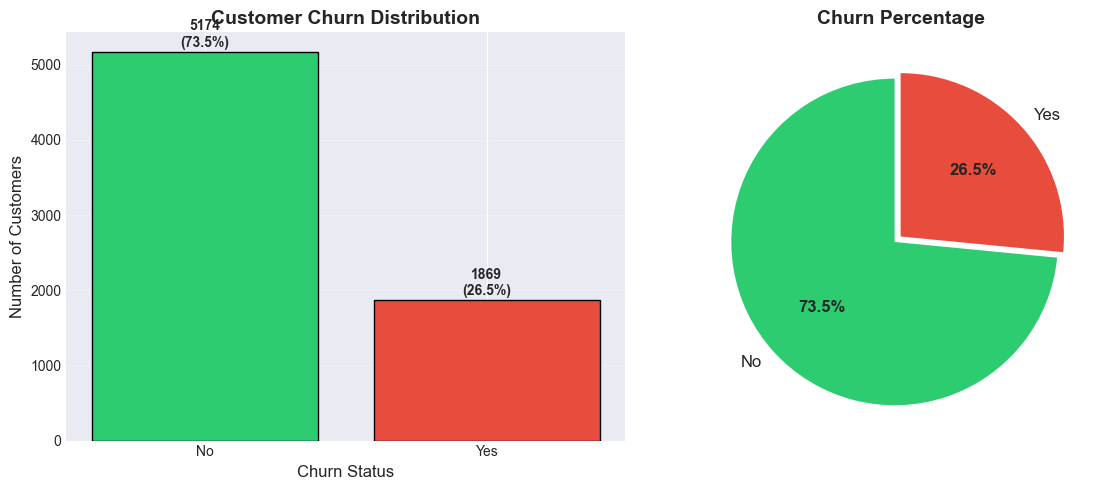

 Created churn distribution visualization!
   No Churn: 5,174 customers (73.5%)
   Churned:  1,869 customers (26.5%)


In [3]:
print("PLOT 1: CHURN DISTRIBUTION")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1.1: Count plot
churn_counts = df['Churn'].value_counts()
bars = axes[0].bar(churn_counts.index, churn_counts.values, 
                   color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Status', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 30,
                f'{int(height)}\n({height/len(df)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# Plot 1.2: Pie chart
churn_percentages = df['Churn'].value_counts(normalize=True) * 100
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(churn_percentages.values, 
                                       labels=churn_percentages.index, 
                                       autopct='%1.1f%%', colors=colors, 
                                       startangle=90, explode=(0.05, 0),
                                       textprops={'fontsize': 12})
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Created churn distribution visualization!")
print(f"   No Churn: {churn_counts['No']:,} customers ({churn_percentages['No']:.1f}%)")
print(f"   Churned:  {churn_counts['Yes']:,} customers ({churn_percentages['Yes']:.1f}%)")


PLOT 2: DEMOGRAPHIC ANALYSIS


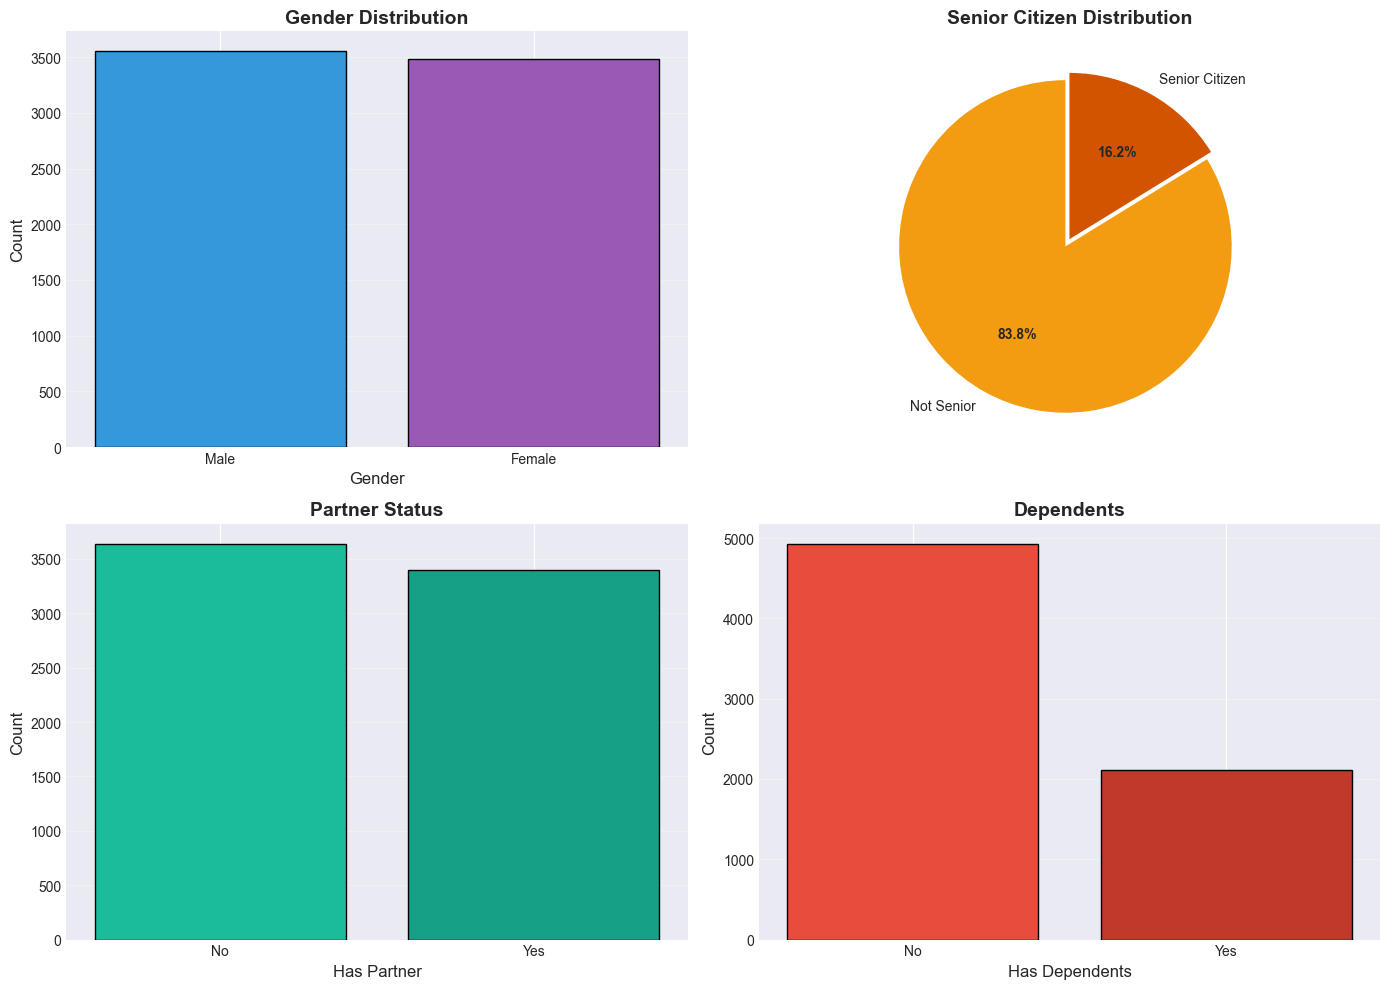

✅ Demographic visualizations created!


In [ ]:
print("DEMOGRAPHIC ANALYSIS")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot 2.1: Gender distribution
gender_counts = df['gender'].value_counts()
bars1 = axes[0].bar(gender_counts.index, gender_counts.values, 
                   color=['#3498db', '#9b59b6'], edgecolor='black')
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2.2: Senior citizen distribution
senior_counts = df['SeniorCitizen'].value_counts()
labels = ['Not Senior', 'Senior Citizen']
wedges2, texts2, autotexts2 = axes[1].pie(senior_counts.values, labels=labels, 
                                         autopct='%1.1f%%', 
                                         colors=['#f39c12', '#d35400'], 
                                         startangle=90, explode=(0.05, 0))
axes[1].set_title('Senior Citizen Distribution', fontsize=14, fontweight='bold')
for autotext in autotexts2:
    autotext.set_fontweight('bold')

# Plot 2.3: Partner status
partner_counts = df['Partner'].value_counts()
bars3 = axes[2].bar(partner_counts.index, partner_counts.values, 
                   color=['#1abc9c', '#16a085'], edgecolor='black')
axes[2].set_title('Partner Status', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Has Partner', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

# Plot 2.4: Dependents
dependent_counts = df['Dependents'].value_counts()
bars4 = axes[3].bar(dependent_counts.index, dependent_counts.values, 
                   color=['#e74c3c', '#c0392b'], edgecolor='black')
axes[3].set_title('Dependents', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Has Dependents', fontsize=12)
axes[3].set_ylabel('Count', fontsize=12)
axes[3].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('demographics.png', dpi=100, bbox_inches='tight')
plt.show()

print("Demographic visualizations created!")

NUMERICAL FEATURES ANALYSIS


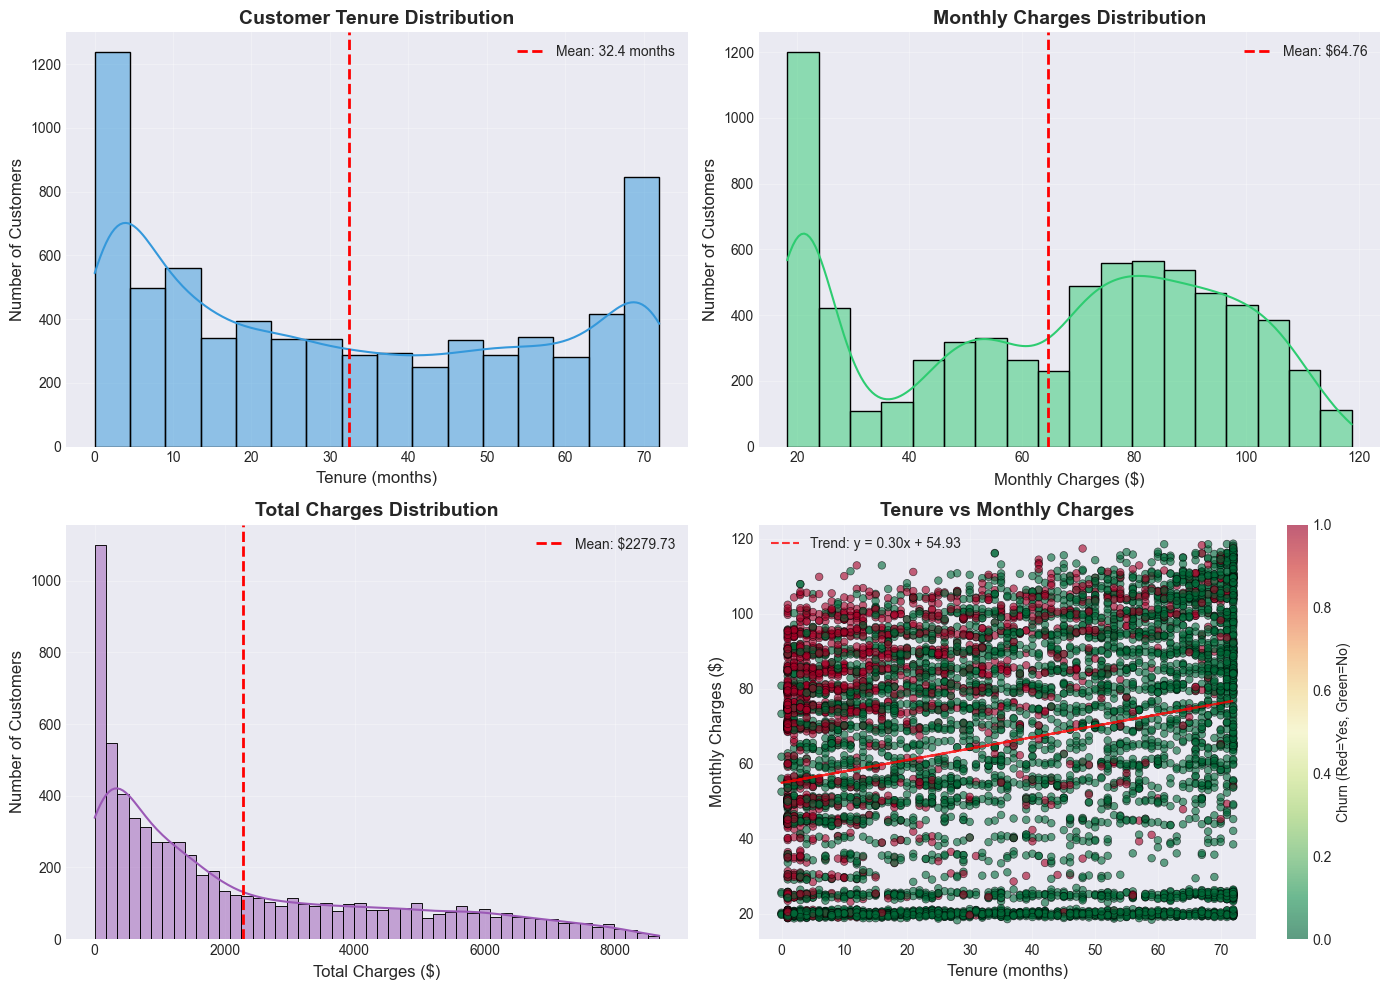

Numerical features visualized!


In [4]:
print("NUMERICAL FEATURES ANALYSIS")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 3.1: Tenure distribution with KDE
sns.histplot(data=df, x='tenure', kde=True, ax=axes[0,0], 
             color='#3498db', edgecolor='black')
axes[0,0].set_title('Customer Tenure Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Tenure (months)', fontsize=12)
axes[0,0].set_ylabel('Number of Customers', fontsize=12)
axes[0,0].axvline(df['tenure'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {df["tenure"].mean():.1f} months')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 3.2: Monthly charges distribution
sns.histplot(data=df, x='MonthlyCharges', kde=True, ax=axes[0,1], 
             color='#2ecc71', edgecolor='black')
axes[0,1].set_title('Monthly Charges Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Monthly Charges ($)', fontsize=12)
axes[0,1].set_ylabel('Number of Customers', fontsize=12)
axes[0,1].axvline(df['MonthlyCharges'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: ${df["MonthlyCharges"].mean():.2f}')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3.3: Total charges distribution
sns.histplot(data=df, x='TotalCharges', kde=True, ax=axes[1,0], 
             color='#9b59b6', edgecolor='black', bins=50)
axes[1,0].set_title('Total Charges Distribution', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Total Charges ($)', fontsize=12)
axes[1,0].set_ylabel('Number of Customers', fontsize=12)
axes[1,0].axvline(df['TotalCharges'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: ${df["TotalCharges"].mean():.2f}')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 3.4: Scatter plot with regression line
scatter = axes[1,1].scatter(df['tenure'], df['MonthlyCharges'], 
                           c=df['Churn'].map({'Yes': 1, 'No': 0}), 
                           cmap='RdYlGn_r', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1,1].set_title('Tenure vs Monthly Charges', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Tenure (months)', fontsize=12)
axes[1,1].set_ylabel('Monthly Charges ($)', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(df['tenure'], df['MonthlyCharges'], 1)
p = np.poly1d(z)
axes[1,1].plot(df['tenure'], p(df['tenure']), "r--", alpha=0.8, 
               label=f'Trend: y = {z[0]:.2f}x + {z[1]:.2f}')
axes[1,1].legend()

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes[1,1])
cbar.set_label('Churn (Red=Yes, Green=No)', fontsize=10)

plt.tight_layout()
plt.savefig('numerical_features.png', dpi=100, bbox_inches='tight')
plt.show()

print("Numerical features visualized!")


PLOT 4: BOXPLOTS BY CHURN STATUS


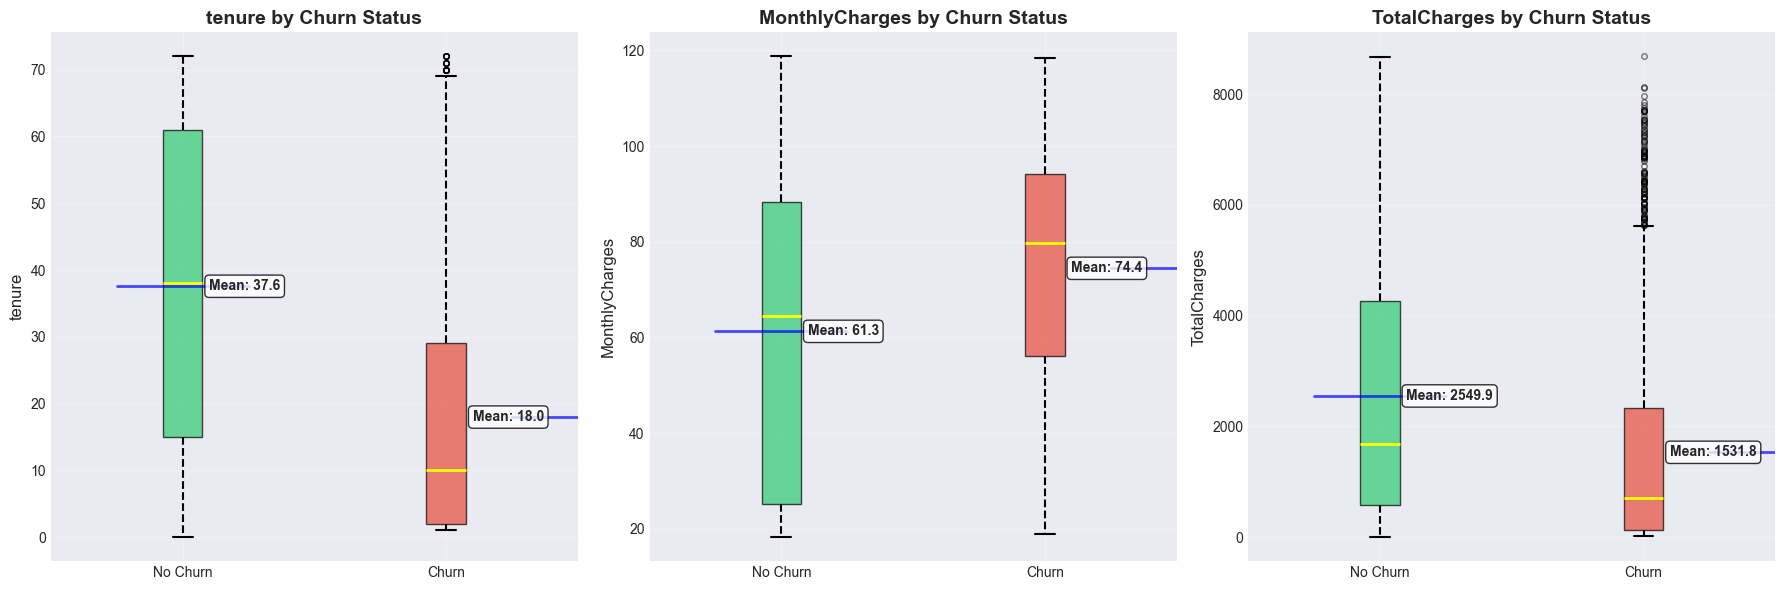

✅ Box plots created successfully!


In [ ]:
print("\n" + "=" * 50)
print("PLOT 4: BOXPLOTS BY CHURN STATUS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    
    # Prepare data for boxplot
    no_churn_data = df[df['Churn'] == 'No'][feature].values
    yes_churn_data = df[df['Churn'] == 'Yes'][feature].values
    
    data_to_plot = [no_churn_data, yes_churn_data]
    
    # Create boxplot with updated parameter name
    box = ax.boxplot(data_to_plot, patch_artist=True)
    
    # Update tick labels separately (FIXED: using set_xticklabels)
    ax.set_xticklabels(['No Churn', 'Churn'])
    
    # Color the boxes
    colors = ['#2ecc71', '#e74c3c']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
    
    # Customize boxplot elements
    for whisker in box['whiskers']:
        whisker.set(color='black', linewidth=1.5, linestyle='--')
    
    for cap in box['caps']:
        cap.set(color='black', linewidth=1.5)
    
    for median in box['medians']:
        median.set(color='yellow', linewidth=2)
    
    for flier in box['fliers']:
        flier.set(marker='o', color='red', alpha=0.5, markersize=4)
    
    ax.set_title(f'{feature} by Churn Status', fontsize=14, fontweight='bold')
    ax.set_ylabel(feature, fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add mean lines and text
    for i, data in enumerate(data_to_plot):
        if len(data) > 0:
            mean_val = np.mean(data)
            ax.axhline(mean_val, xmin=0.125 + i*0.75, xmax=0.375 + i*0.75, 
                       color='blue', linestyle='-', linewidth=2, alpha=0.7)
            ax.text(i + 1.1, mean_val, f'Mean: {mean_val:.1f}', 
                    va='center', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('boxplots_by_churn.png', dpi=100, bbox_inches='tight')
plt.show()

print("Box plots created successfully!")



PLOT 5: CONTRACT & PAYMENT ANALYSIS


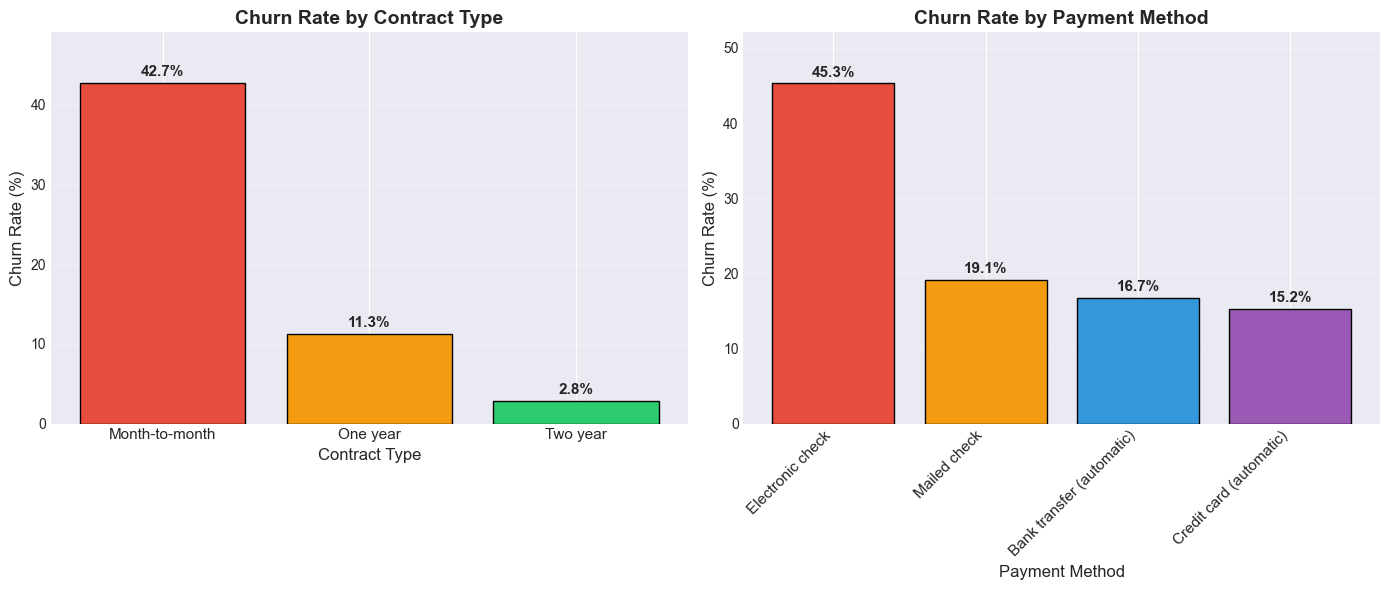

✅ Contract and payment analysis completed!


In [ ]:
print("\n" + "=" * 50)
print("PLOT 5: CONTRACT & PAYMENT ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 5.1: Contract type analysis
contract_data = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100
contract_data = contract_data.sort_values(ascending=False)

bars1 = axes[0].bar(range(len(contract_data)), contract_data.values, 
                   color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0].set_xticks(range(len(contract_data)))
axes[0].set_xticklabels(contract_data.index, fontsize=11)
axes[0].set_ylim(0, contract_data.max() * 1.15)
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)

# Plot 5.2: Payment method analysis
payment_data = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100
payment_data = payment_data.sort_values(ascending=False)

x_pos = range(len(payment_data))
bars2 = axes[1].bar(x_pos, payment_data.values, 
                   color=['#e74c3c', '#f39c12', '#3498db', '#9b59b6'],
                   edgecolor='black')
axes[1].set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Payment Method', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(payment_data.index, rotation=45, ha='right', fontsize=11)
axes[1].set_ylim(0, payment_data.max() * 1.15)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, value) in enumerate(zip(bars2, payment_data.values)):
    axes[1].text(bar.get_x() + bar.get_width()/2., value + 0.5,
                f'{value:.1f}%', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('contract_payment_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("Contract and payment analysis completed!")



PLOT 6: CORRELATION HEATMAP


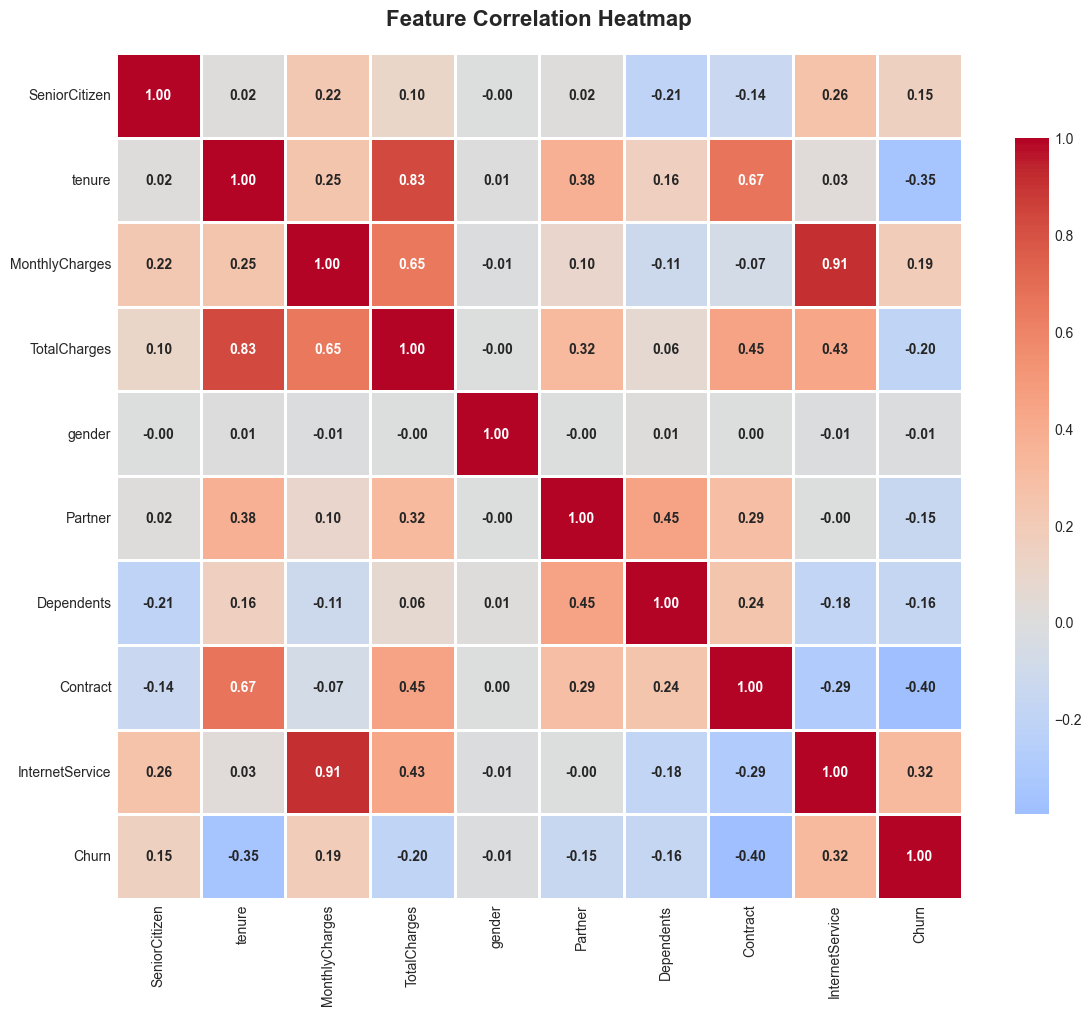

✅ Correlation heatmap created!

DAY 2 SUMMARY & KEY INSIGHTS

📊 KEY STATISTICS:
   Total Customers: 7,043
   Overall Churn Rate: 26.5%
   Average Tenure: 32.4 months
   Average Monthly Charge: $64.76

🔍 TOP INSIGHTS:
   1. HIGHEST CHURN RATES:
      - Month-to-month contracts: 42.7% churn

   2. KEY CORRELATIONS WITH CHURN:
      - InternetService: 0.317 (churn increases with higher InternetService)
      - tenure: -0.352 (churn decreases with higher tenure)
      - Contract: -0.397 (churn decreases with higher Contract)

   3. DEMOGRAPHIC PATTERNS:
      - Senior Citizens: 41.7% churn
      - Non-Seniors: 23.6% churn
      - Difference: 18.1 percentage points
      - With Partner: 19.7% churn
      - Without Partner: 33.0% churn
      - Difference: 13.3 percentage points
      - With Dependents: 15.5% churn
      - Without Dependents: 31.3% churn
      - Difference: 15.8 percentage points

📈 VISUALIZATIONS CREATED:
   1. churn_distribution.png
   2. demographics.png
   3. numerical_fe

In [ ]:
print("\n" + "=" * 50)
print("PLOT 6: CORRELATION HEATMAP")
print("=" * 50)

# Prepare data for correlation
df_corr = df.copy()

# Convert categorical to numerical for correlation
binary_map = {'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1}
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 
            'PaperlessBilling', 'Churn']:
    df_corr[col] = df_corr[col].map(binary_map)

# Map other categories
df_corr['Contract'] = df_corr['Contract'].map({'Month-to-month': 0, 
                                               'One year': 1, 
                                               'Two year': 2})
df_corr['InternetService'] = df_corr['InternetService'].map({'No': 0, 
                                                            'DSL': 1, 
                                                            'Fiber optic': 2})

# Select columns for correlation
corr_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
                'gender', 'Partner', 'Dependents', 'Contract',
                'InternetService', 'Churn']
corr_matrix = df_corr[corr_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, linecolor='white',
            cbar_kws={"shrink": 0.8}, fmt='.2f',
            annot_kws={'size': 10, 'weight': 'bold'})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("Correlation heatmap created!")



print("SUMMARY & KEY INSIGHTS")

print("\n KEY STATISTICS:")
print(f"   Total Customers: {len(df):,}")
print(f"   Overall Churn Rate: {(df['Churn'] == 'Yes').mean()*100:.1f}%")
print(f"   Average Tenure: {df['tenure'].mean():.1f} months")
print(f"   Average Monthly Charge: ${df['MonthlyCharges'].mean():.2f}")

print("\n TOP INSIGHTS:")
print("   1. HIGHEST CHURN RATES:")
for feature, rate in contract_data.items():
    if rate > 40:
        print(f"      - {feature} contracts: {rate:.1f}% churn")

print("\n   2. KEY CORRELATIONS WITH CHURN:")
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
for feature, corr in churn_corr.items():
    if feature != 'Churn' and abs(corr) > 0.2:
        direction = "increases" if corr > 0 else "decreases"
        print(f"      - {feature}: {corr:.3f} (churn {direction} with higher {feature})")

print("\n   3. DEMOGRAPHIC PATTERNS:")

# First, create a numeric version of Churn for calculations
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Calculate churn rates for each demographic feature
senior_churn = df.groupby('SeniorCitizen')['Churn_numeric'].mean() * 100
partner_churn = df.groupby('Partner')['Churn_numeric'].mean() * 100
dependents_churn = df.groupby('Dependents')['Churn_numeric'].mean() * 100

# Senior Citizen analysis
if len(senior_churn) > 1:
    senior_diff = abs(senior_churn[1] - senior_churn[0])
    if senior_diff > 10:
        print(f"      - Senior Citizens: {senior_churn[1]:.1f}% churn")
        print(f"      - Non-Seniors: {senior_churn[0]:.1f}% churn")
        print(f"      - Difference: {senior_diff:.1f} percentage points")

# Partner analysis
if len(partner_churn) > 1:
    partner_diff = abs(partner_churn['Yes'] - partner_churn['No'])
    if partner_diff > 10:
        print(f"      - With Partner: {partner_churn['Yes']:.1f}% churn")
        print(f"      - Without Partner: {partner_churn['No']:.1f}% churn")
        print(f"      - Difference: {partner_diff:.1f} percentage points")

# Dependents analysis
if len(dependents_churn) > 1:
    dependents_diff = abs(dependents_churn['Yes'] - dependents_churn['No'])
    if dependents_diff > 10:
        print(f"      - With Dependents: {dependents_churn['Yes']:.1f}% churn")
        print(f"      - Without Dependents: {dependents_churn['No']:.1f}% churn")
        print(f"      - Difference: {dependents_diff:.1f} percentage points")


print("\nVISUALIZATIONS CREATED:")
print("   1. churn_distribution.png")
print("   2. demographics.png")
print("   3. numerical_features.png")
print("   4. boxplots_by_churn.png")
print("   5. contract_payment_analysis.png")
print("   6. correlation_heatmap.png")



# Save cleaned data for tomorrow
df.to_csv('telco_churn_cleaned.csv', index=False)
print("\n💾 Cleaned data saved as 'telco_churn_cleaned.csv' !")